# Emotion Analysis


In [ ]:
!pip install tweet-preprocessor 2>/dev/null 1>/dev/null
!pip install emoji
!pip install np_utils
!pip install hazm
!pip install plotly
! pip install --upgrade tensorflow==2.15

  Using cached tensorflow-2.15.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.4 kB)
  Using cached ml_dtypes-0.2.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
  Using cached wrapt-1.14.1-cp310-cp310-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.7 kB)
  Using cached tensorboard-2.15.2-py3-none-any.whl.metadata (1.7 kB)
  Using cached tensorflow_estimator-2.15.0-py2.py3-none-any.whl.metadata (1.3 kB)
  Using cached keras-2.15.0-py3-none-any.whl.metadata (2.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.2/475.2 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 114.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os

os.environ['TF_USE_LEGACY_KERAS'] = '1'

In [ ]:
import preprocessor as p
import numpy as np
import pandas as pd
from hazm import *
import emoji
import keras
from sklearn.model_selection import train_test_split
import tensorflow as tf
from keras.models import Sequential
from keras.layers import LSTM, GRU,SimpleRNN
from keras.layers import Dense, Activation, Dropout
from keras.layers import Embedding
from keras.layers import BatchNormalization
import np_utils
from sklearn import preprocessing, decomposition, model_selection, metrics, pipeline
from keras.layers import GlobalMaxPooling1D, Conv1D, MaxPooling1D, Flatten, Bidirectional, SpatialDropout1D
from keras.preprocessing import sequence
from tensorflow.keras.preprocessing import text
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
import plotly.graph_objects as go
import plotly.express as px
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint
# from kaggle_datasets import KaggleDatasets
import transformers
from transformers import TFAutoModel, AutoTokenizer
from tqdm.notebook import tqdm
from tqdm import tqdm

In [ ]:
print(tf.__version__)

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
DATAPATH = "Dataset"

Mounted at /content/drive


# Data preparation  <a class="anchor" id="toc"></a>


In [ ]:
data = pd.read_csv(DATAPATH + "./train.tsv", sep='\t',names=["text", "feeling"])
test_data = pd.read_csv(DATAPATH + "./test.tsv", sep='\t',names=["text", "feeling"])
df_merged = pd.concat([data, test_data], ignore_index=True, sort=False)
data, test_data = train_test_split(df_merged, test_size=0.2)

In [ ]:
data = data[data["feeling"]!="OTHER"]
test_data = test_data[test_data["feeling"]!="OTHER"]

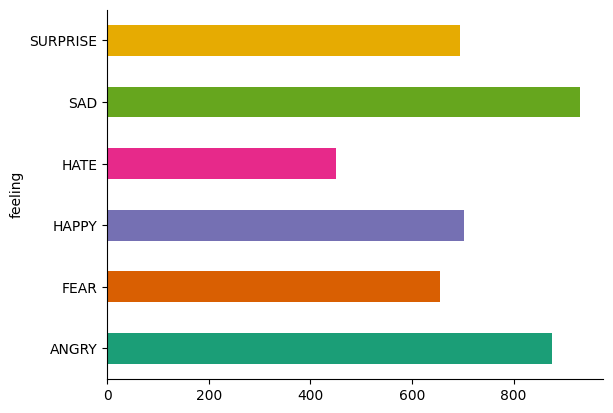

In [ ]:
# @title feeling

from matplotlib import pyplot as plt
import seaborn as sns
data.groupby('feeling').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
test_data

,text,feeling
7250,خشونت زخمی می کند و می شکند؛ التیام هم ندارد.....,SAD
1961,بحران #٣٠سالگي براي من فقط بحران مالي بود ، كه...,SAD
4196,چقدر خشنی تو آخه پسر چشم حسودت کور,SURPRISE
1506,رفتم آرایشگاه موهامو کوتاه کردم. به خانومه گفت...,SAD
4313,اتفاقا خیلی ترسوام,FEAR
...,...,...
5883,از آلبالو و مربای آلبالو و آلبالوپلو متنفرررررم,HATE
6000,خارشونو سگ گایید. مملکتم دقیقا همینجوری قسمت م...,ANGRY
6856,پاسخ شایسته علی انصاریان بازیکن سابق فوتبال به...,HAPPY
2313,این رزمایش سداد رید به اعصابم. یعنی یه ذره امی...,ANGRY


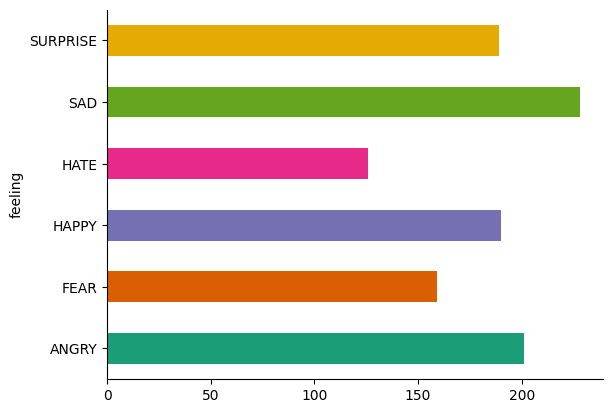

In [ ]:
# @title feeling

from matplotlib import pyplot as plt
import seaborn as sns
test_data.groupby('feeling').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

### Stop words

In [ ]:
def read_stopwords(file_path):
    with open(file=file_path, mode='r',encoding='utf-8', errors='ignore') as file:
        stopwords = file.readlines()
    stopwords = [word.strip() for word in stopwords]
    return stopwords

def remove_stopwords(text, stopwords):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stopwords]
    filtered_text = ' '.join(filtered_words)
    return filtered_text

stopwords = read_stopwords(DATAPATH + 'stop-words.txt')
tqdm.pandas()
data['text'] = data['text'].progress_apply(lambda x: remove_stopwords(x, stopwords))
test_data['text'] = test_data['text'].progress_apply(lambda x: remove_stopwords(x, stopwords))
